# 02 — Exploratory Data Analysis
**Project:** AI-Powered Essay Evaluation & Writing Assistant — Review 1

**Confirmed in `01_dataset_understanding.ipynb`:** 24,728 rows x 14 columns, no fully-blank rows, no duplicate `essay_id`, 7 unique prompts. This notebook goes deeper: distributions, essay-length features, per-prompt breakdowns, and the visualizations required for Review 1.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('../src')
from data.load_data import load_raw_data, DEMOGRAPHIC_COLUMNS

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RAW_PATH = '../data/raw/ASAP2_train_sourcetexts.csv'
FIG_DIR = '../results/figures'

df = load_raw_data(RAW_PATH)
df.shape

(24728, 14)

## 1. Dataset structure recap

In [8]:
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)

Shape: (24728, 14)

Dtypes:
essay_id                        str
score                         int64
full_text                       str
assignment                      str
prompt_name                     str
economically_disadvantaged      str
student_disability_status       str
ell_status                      str
race_ethnicity                  str
gender                          str
source_text_1                   str
source_text_2                   str
source_text_3                   str
source_text_4                   str
dtype: object


## 2. Missing values

We look at missing values per column. Note: missingness in `source_text_2/3/4` is *expected* --
not every prompt provides multiple source texts, so this is not a data quality bug, it's how the
dataset is structured (single-source vs multi-source prompts).

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table[missing_table['missing_count'] > 0]

,missing_count,missing_pct
source_text_4,22769,92.08
source_text_2,20723,83.80
source_text_3,20723,83.80
student_disability_status,4005,16.20
economically_disadvantaged,4005,16.20
ell_status,442,1.79
race_ethnicity,4,0.02


## 3. Duplicates

In [10]:
print('Fully duplicate rows:', df.duplicated().sum())
print('Duplicate essay_id:', df['essay_id'].duplicated().sum())
print('Duplicate full_text (same essay text used twice):', df['full_text'].duplicated().sum())

Fully duplicate rows: 0
Duplicate essay_id: 0
Duplicate full_text (same essay text used twice): 0


## 4. Unique values in key columns

In [11]:
print('Unique assignments:', df['assignment'].nunique())
print('Unique prompt_names:', df['prompt_name'].nunique())
print()
print('Prompt names:')
print(df['prompt_name'].unique())

Unique assignments: 7
Unique prompt_names: 7

Prompt names:
<StringArray>
[                 'Exploring Venus',      'Facial action coding system',
                 'The Face on Mars',    '"A Cowboy Who Rode the Waves"',
                  'Driverless cars', 'Does the electoral college work?',
                  'Car-free cities']
Length: 7, dtype: str


## 5. Score analysis

Core statistics required for Review 1: min, max, mean, median, std, and the full frequency table.

In [12]:
score_stats = df['score'].describe()
score_stats

count    24728.000000
mean         2.939987
std          1.035991
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: score, dtype: float64

In [13]:
score_counts = df['score'].value_counts().sort_index()
score_counts

score
1    1751
2    6847
3    9021
4    5553
5    1356
6     200
Name: count, dtype: int64

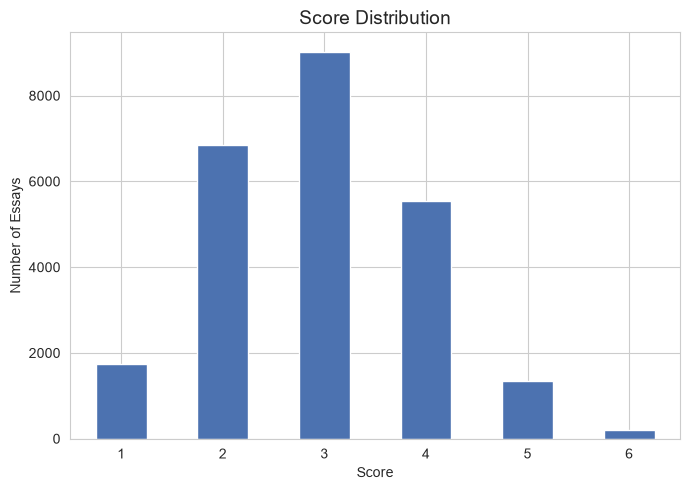

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
score_counts.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Score Distribution', fontsize=14)
ax.set_xlabel('Score')
ax.set_ylabel('Number of Essays')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_score_distribution.png')
plt.show()

## 6. Essay length features (temporary, for EDA only)

We compute `character_count`, `word_count`, and `sentence_count` here purely to explore the data.
These are NOT saved back into the cleaned dataset yet -- that happens properly in
`03_preprocessing_and_features.ipynb` alongside the rest of the handcrafted features.

In [15]:
def sentence_count(text):
    # simple, dependency-free approximation for EDA purposes
    # (proper sentence splitting with spaCy/NLTK comes in notebook 03)
    for ch in ['!', '?']:
        text = text.replace(ch, '.')
    parts = [p for p in text.split('.') if p.strip()]
    return len(parts)

df['character_count'] = df['full_text'].str.len()
df['word_count'] = df['full_text'].str.split().str.len()
df['sentence_count'] = df['full_text'].apply(sentence_count)

df[['character_count', 'word_count', 'sentence_count']].describe()

,character_count,word_count,sentence_count
count,24728.000000,24728.000000,24728.000000
mean,2035.663499,362.897282,19.565027
std,900.741907,148.461603,8.703055
min,697.000000,150.000000,1.000000
25%,1376.000000,249.000000,13.000000
50%,1881.000000,338.000000,18.000000
75%,2501.000000,446.000000,25.000000
max,20459.000000,1656.000000,135.000000


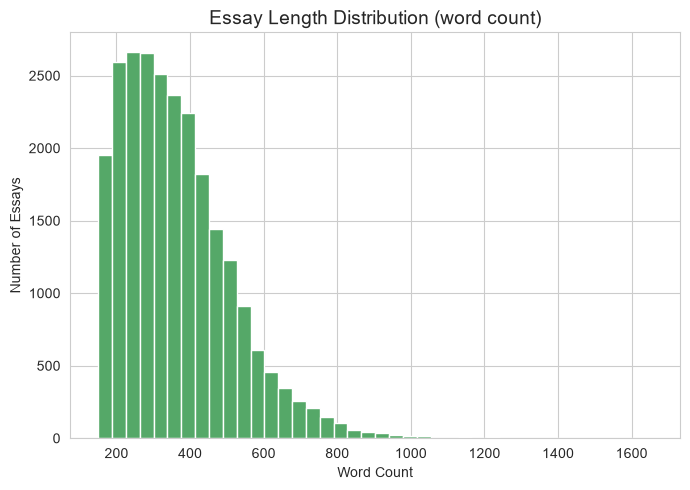

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df['word_count'], bins=40, color='#55A868', edgecolor='white')
ax.set_title('Essay Length Distribution (word count)', fontsize=14)
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Essays')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_essay_length_distribution.png')
plt.show()

## 7. Score vs essay length

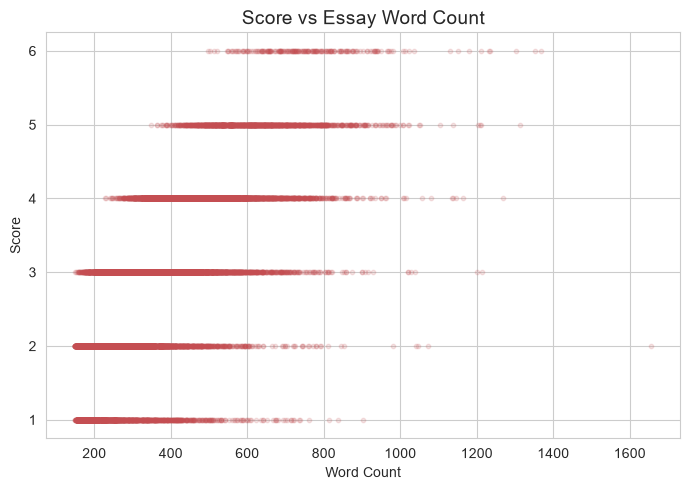

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['word_count'], df['score'], alpha=0.15, s=10, color='#C44E52')
ax.set_title('Score vs Essay Word Count', fontsize=14)
ax.set_xlabel('Word Count')
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_score_vs_length_scatter.png')
plt.show()

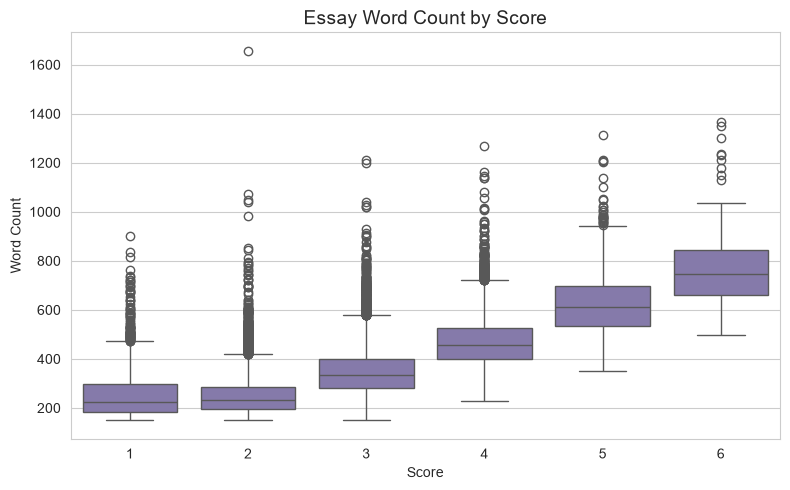

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='score', y='word_count', data=df, ax=ax, color='#8172B2')
ax.set_title('Essay Word Count by Score', fontsize=14)
ax.set_xlabel('Score')
ax.set_ylabel('Word Count')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_wordcount_by_score_boxplot.png')
plt.show()

**What to look for:** if higher scores tend to have a higher median word count and the boxes
trend upward, essay length is likely a useful (though not sufficient on its own) predictive signal.
This does NOT mean "longer = automatically better" -- it's a correlation to investigate, not a rule
to hard-code into the model.

## 8. Assignment / prompt analysis

In [19]:
essays_per_assignment = df['prompt_name'].value_counts()
essays_per_assignment

prompt_name
Driverless cars                     6170
Facial action coding system         4883
Exploring Venus                     4480
The Face on Mars                    3015
"A Cowboy Who Rode the Waves"       2175
Does the electoral college work?    2046
Car-free cities                     1959
Name: count, dtype: int64

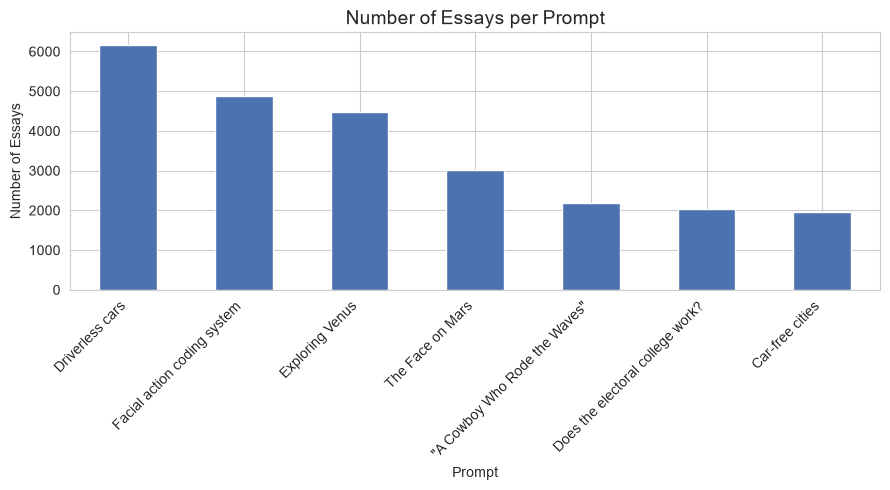

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
essays_per_assignment.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Number of Essays per Prompt', fontsize=14)
ax.set_xlabel('Prompt')
ax.set_ylabel('Number of Essays')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_essays_per_assignment.png')
plt.show()

In [21]:
score_by_prompt = df.groupby('prompt_name')['score'].agg(['mean', 'std', 'min', 'max', 'count']).round(2)
score_by_prompt.sort_values('mean', ascending=False)

,mean,std,min,max,count
prompt_name,,,,,
Driverless cars,3.20,0.95,1,6,6170
Car-free cities,3.10,1.06,1,6,1959
Facial action coding system,3.06,1.03,1,6,4883
Does the electoral college work?,3.00,1.15,1,6,2046
The Face on Mars,2.73,0.98,1,6,3015
Exploring Venus,2.72,1.08,1,6,4480
"""A Cowboy Who Rode the Waves""",2.48,0.82,1,5,2175


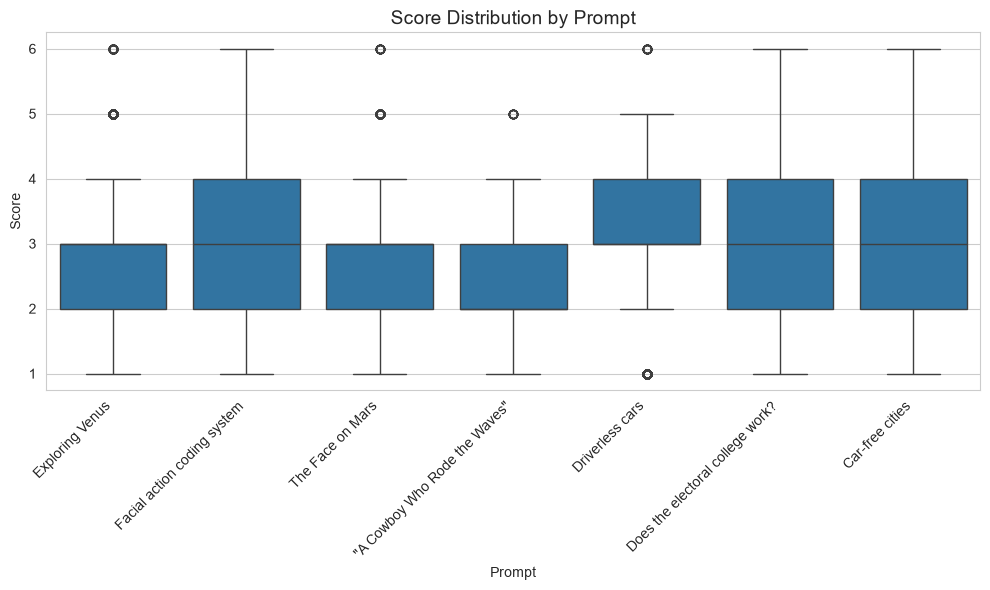

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='prompt_name', y='score', data=df, ax=ax)
ax.set_title('Score Distribution by Prompt', fontsize=14)
ax.set_xlabel('Prompt')
ax.set_ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_score_by_prompt_boxplot.png')
plt.show()

**Why this matters:** if different prompts have very different score distributions (some
systematically scored higher/lower), that's a signal the prompt itself may need to be part of the
feature set later, or that we should be cautious comparing raw scores across prompts.

## 9. Correlation heatmap

Only numeric features -- we do NOT correlate categorical/string columns (that would be meaningless).

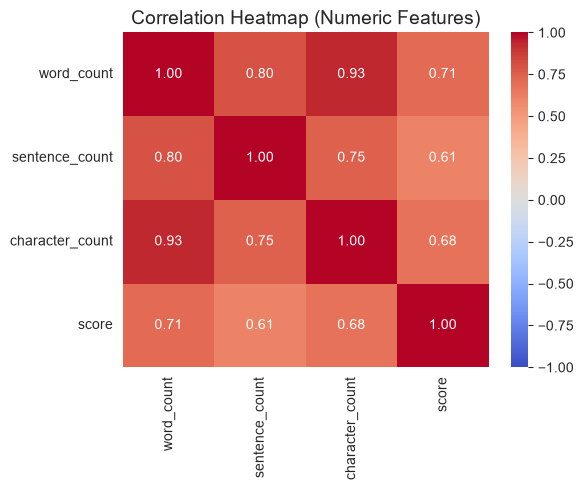

In [23]:
numeric_cols = ['word_count', 'sentence_count', 'character_count', 'score']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_correlation_heatmap.png')
plt.show()

## 10. Summary

- No missing essays or scores; missingness is confined to optional source-text columns and
  demographic fields (which are excluded from modeling anyway).
- No duplicate essays.
- Score is skewed toward the middle of the 1-6 scale, with few essays at the extremes (1 and 6) --
  worth remembering when training/evaluating, since the model will see far fewer examples of
  extreme scores.
- Essay length (word count) shows a visible relationship with score in the boxplot/scatter --
  a reasonable candidate feature, not a proxy for the whole task.
- Score distributions differ somewhat by prompt, which is expected and something to keep in mind
  when interpreting a single global score-vs-length relationship.
- All figures required are saved to `results/figures/` for direct use in the report/slides.